# Bước 1: Khai báo thư viện và Đọc dữ liệu
**Đầu tiên, chúng ta tải các công cụ cần thiết và nạp dữ liệu vào.**


In [1]:
# Cài đặt thư viện PSO (Chạy lệnh này trong 1 cell riêng trên cùng)
!pip install pyswarms -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.0 MB/s eta 0:00:00


In [2]:


import numpy as np
import pandas as pd
import pyswarms as ps
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 1. ĐỌC DỮ LIỆU
# Thêm dấu '/' vào cuối đường dẫn để khi nối chuỗi không bị lỗi
data_path = '/kaggle/input/datasets/hongngc12/predict-custumer-churn/' 

# Sử dụng biến data_path để code ngắn gọn và dễ nhìn hơn
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
sample_sub = pd.read_csv(data_path + 'sample_submission.csv')

print(f"Kích thước tập Train: {train.shape}")
print(f"Kích thước tập Test: {test.shape}")

Kích thước tập Train: (594194, 21)
Kích thước tập Test: (254655, 20)


# Bước 2: Làm sạch và Tiền xử lý dữ liệu (Data Preprocessing)


In [3]:
# 1. LOẠI BỎ CÁC CỘT KHÔNG CÓ GIÁ TRỊ DỰ ĐOÁN
# Cột 'id' chỉ là số thứ tự, không giúp ích cho việc dự đoán khách hàng rời bỏ
# Nếu dữ liệu có cột 'CustomerId' hoặc 'Surname' (Tên khách hàng), bạn cũng nên bỏ đi
cols_to_drop = ['id'] 
# cols_to_drop = ['id', 'CustomerId', 'Surname'] # Bỏ comment dòng này nếu có các cột đó

# Lưu lại id của tập test để làm file nộp bài sau này
test_ids = test['id']

X = train.drop(columns=cols_to_drop + ['Churn']) # Tập đặc trưng
y = train['Churn']                               # Tập nhãn (Mục tiêu)
X_test = test.drop(columns=cols_to_drop)

# 2. XỬ LÝ DỮ LIỆU BỊ THIẾU (MISSING VALUES)
# Điền số trung bình (mean) cho các cột dạng số bị trống
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
imputer_num = SimpleImputer(strategy='mean')
X[num_cols] = imputer_num.fit_transform(X[num_cols])
X_test[num_cols] = imputer_num.transform(X_test[num_cols])

# 3. MÃ HÓA CÁC BIẾN CHỮ (CATEGORICAL ENCODING)
# Phân loại khách hàng rời bỏ thường có các cột chữ như Gender (Nam/Nữ), Geography (Quốc gia)
cat_cols = X.select_dtypes(include=['object']).columns

# Sử dụng Label Encoding (Biến chữ thành các số 0, 1, 2...)
for col in cat_cols:
    le = LabelEncoder()
    # Huấn luyện Label Encoder trên cả tập train và test để tránh lỗi nếu test có từ mới
    le.fit(list(X[col].astype(str)) + list(X_test[col].astype(str)))
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("Dữ liệu sau khi làm sạch:")
display(X.head())

Dữ liệu sau khi làm sạch:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0.0,1,1,29.0,1,0,0,2,0,2,2,0,0,1,1,3,60.10,1653.85
1,1,0.0,1,1,58.0,1,0,0,2,2,0,2,2,0,2,0,1,69.50,3778.20
2,1,0.0,1,0,58.0,1,2,1,0,2,0,0,2,2,0,1,2,100.40,5841.35
3,0,0.0,0,0,1.0,1,0,1,0,0,0,0,0,0,0,1,2,69.70,70.70
4,0,0.0,0,0,1.0,1,0,1,0,0,0,0,0,0,0,1,2,70.45,70.45


# Bước 3: Áp dụng PSO để Lọc Đặc Trưng

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Chuyển đổi sang numpy array
X_matrix = X.values
y_vector = y.values

# ĐỊNH NGHĨA HÀM ĐÁNH GIÁ (FITNESS FUNCTION)
def fitness_function(m):
    scores = []
    for i in range(m.shape[0]):
        mask = m[i, :] > 0.5
        if np.count_nonzero(mask) == 0:
            scores.append(0.0)
            continue
            
        X_subset = X_matrix[:, mask]
        clf = LGBMClassifier(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
        auc = cross_val_score(clf, X_subset, y_vector, cv=3, scoring='roc_auc').mean()
        scores.append(-auc)
    return np.array(scores)

# THIẾT LẬP VÀ CHẠY PSO
print("Bắt đầu PSO tìm đặc trưng tốt nhất...")
n_features = X_matrix.shape[1]

# ✅ Sửa: k phải nhỏ hơn n_particles
n_particles = 10
k = min(5, n_particles - 1)  # Đảm bảo k < n_particles
options = {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': k, 'p': 2}

optimizer = ps.discrete.binary.BinaryPSO(n_particles=n_particles, dimensions=n_features, options=options)

# Chạy 15 vòng lặp (bạn có thể tăng lên nếu có nhiều thời gian)
cost, pos = optimizer.optimize(fitness_function, iters=15)

# LỌC LẠI TẬP DỮ LIỆU
selected_features = X.columns[pos == 1]
print(f"\nGiữ lại {len(selected_features)} / {n_features} đặc trưng:")
print(list(selected_features))
X_optimized = X[selected_features]
X_test_optimized = X_test[selected_features]

2026-03-20 13:42:56,663 - pyswarms.discrete.binary - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 5, 'p': 2}


Bắt đầu PSO tìm đặc trưng tốt nhất...


pyswarms.discrete.binary: 100%|██████████|15/15, best_cost=-0.913
2026-03-20 13:56:26,492 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: -0.9128116213969957, best pos: [1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1]



Giữ lại 16 / 19 đặc trưng:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


# Bước 4: Huấn luyện mô hình cuối cùng và Nộp bài

In [5]:
print("Đang huấn luyện mô hình cuối cùng trên các đặc trưng đã chọn...")

# Khởi tạo mô hình xịn (tăng n_estimators)
final_model = LGBMClassifier(
    n_estimators=500, 
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)

# Train trên toàn bộ tập dữ liệu (với các cột đã được chọn)
final_model.fit(X_optimized, y)

# Dự đoán xác suất cho tập Test
test_preds = final_model.predict_proba(X_test_optimized)[:, 1]

# Tạo file nộp bài
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_preds
})

submission.to_csv('submission_pso_lgbm.csv', index=False)
print("Hoàn tất! Bạn có thể tải file submission_pso_lgbm.csv để nộp lên Kaggle.")

Đang huấn luyện mô hình cuối cùng trên các đặc trưng đã chọn...
Hoàn tất! Bạn có thể tải file submission_pso_lgbm.csv để nộp lên Kaggle.


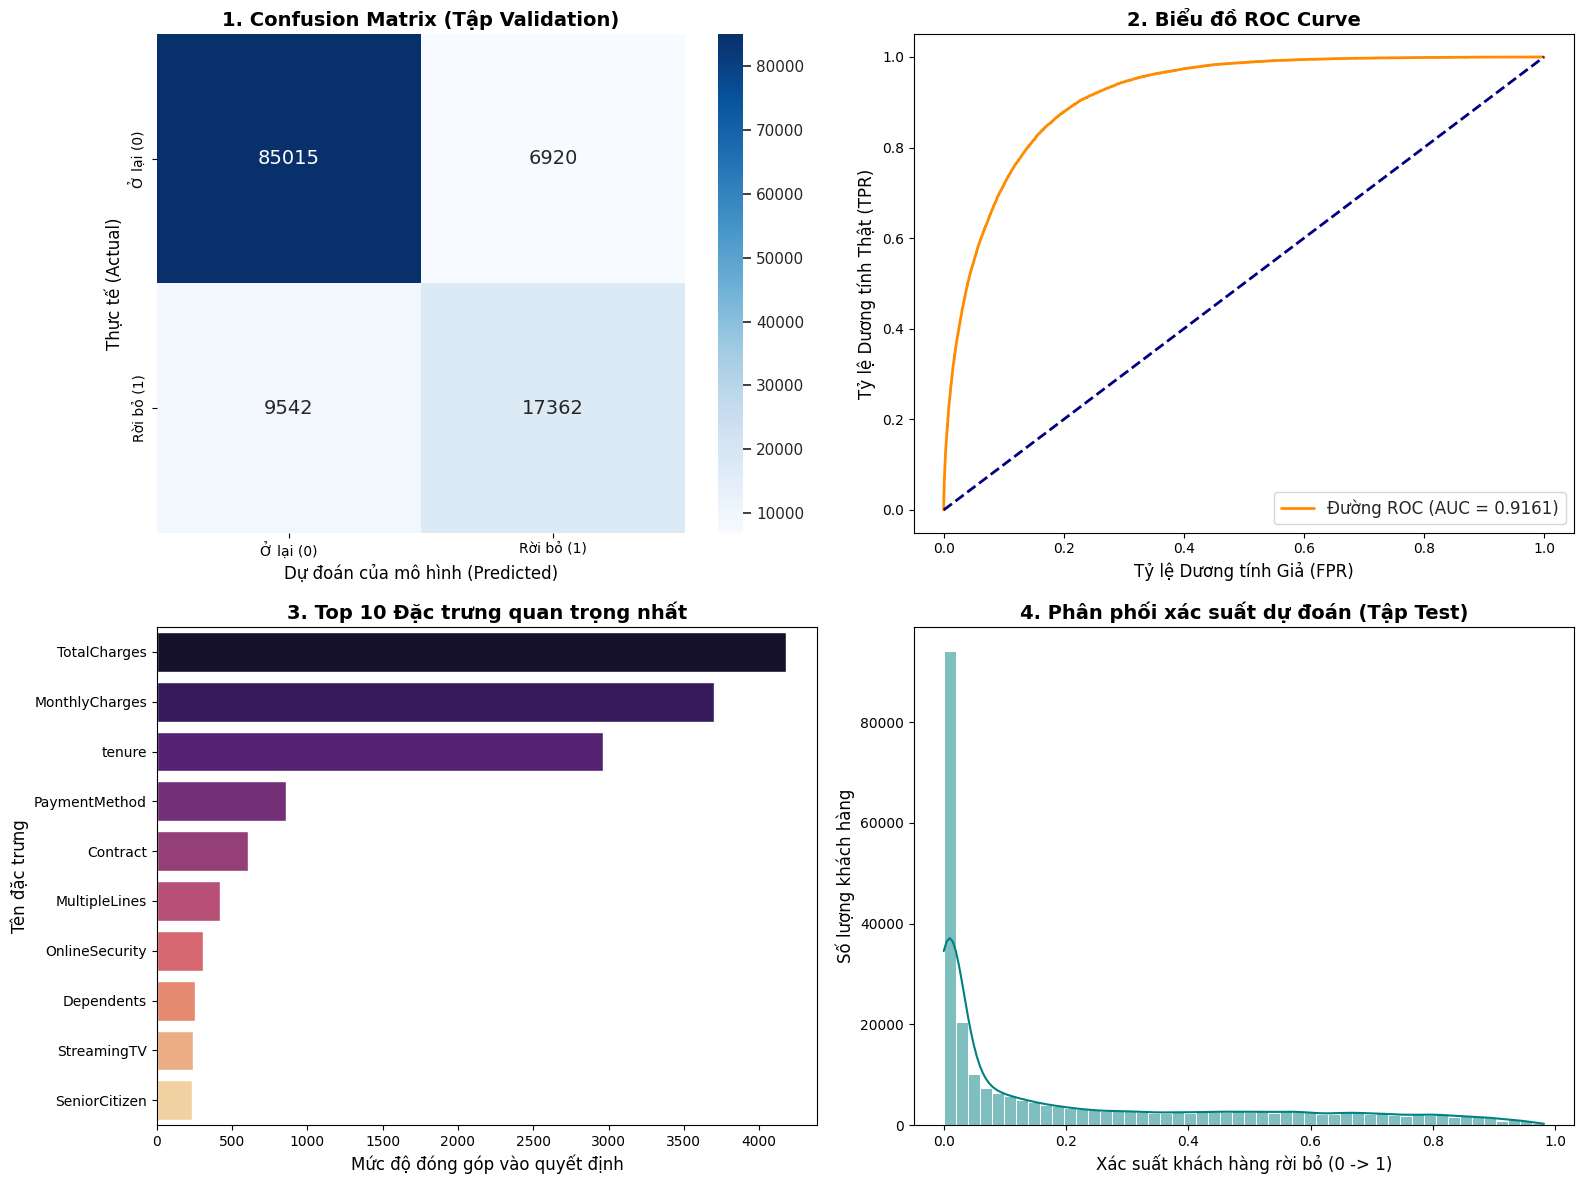

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Tách 20% dữ liệu từ X_optimized để kiểm tra và vẽ biểu đồ
X_tr, X_val, y_tr, y_val = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

# Huấn luyện lại mô hình nhanh trên tập này
vis_model = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
vis_model.fit(X_tr, y_tr)

# Lấy xác suất và chuyển thành nhãn 0/1 (Ngưỡng 0.5)
val_preds_proba = vis_model.predict_proba(X_val)[:, 1]
val_preds_class = (val_preds_proba > 0.5).astype(int)

# --- KHẮC PHỤC LỖI Ở ĐÂY ---
# Chuyển đổi nhãn thực tế ('No'/'Yes') thành số (0/1) để hàm có thể vẽ được
le = LabelEncoder()
y_val_numeric = le.fit_transform(y_val)

# 2. THIẾT LẬP KHUNG VẼ GỒM 4 BIỂU ĐỒ (2 Hàng x 2 Cột)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# --- BIỂU ĐỒ 1: CONFUSION MATRIX (MA TRẬN NHẦM LẪN) ---
cm = confusion_matrix(y_val_numeric, val_preds_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], annot_kws={"size": 14})
axes[0, 0].set_title('1. Confusion Matrix (Tập Validation)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Dự đoán của mô hình (Predicted)', fontsize=12)
axes[0, 0].set_ylabel('Thực tế (Actual)', fontsize=12)
axes[0, 0].xaxis.set_ticklabels(['Ở lại (0)', 'Rời bỏ (1)'])
axes[0, 0].yaxis.set_ticklabels(['Ở lại (0)', 'Rời bỏ (1)'])

# --- BIỂU ĐỒ 2: ROC CURVE (ĐƯỜNG CONG ROC) ---
fpr, tpr, thresholds = roc_curve(y_val_numeric, val_preds_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Đường ROC (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('2. Biểu đồ ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tỷ lệ Dương tính Giả (FPR)', fontsize=12)
axes[0, 1].set_ylabel('Tỷ lệ Dương tính Thật (TPR)', fontsize=12)
axes[0, 1].legend(loc="lower right", fontsize=12)

# --- BIỂU ĐỒ 3: FEATURE IMPORTANCE (ĐẶC TRƯNG QUAN TRỌNG NHẤT) ---
importances = vis_model.feature_importances_
features = X_optimized.columns
# Lấy ra Top 10 đặc trưng quan trọng nhất
indices = np.argsort(importances)[::-1][:10] 
sns.barplot(x=importances[indices], y=features[indices], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('3. Top 10 Đặc trưng quan trọng nhất', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Mức độ đóng góp vào quyết định', fontsize=12)
axes[1, 0].set_ylabel('Tên đặc trưng', fontsize=12)

# --- BIỂU ĐỒ 4: PHÂN PHỐI DỰ ĐOÁN TRÊN TẬP TEST ---
sns.histplot(submission['Churn'], bins=50, kde=True, color='teal', ax=axes[1, 1])
axes[1, 1].set_title('4. Phân phối xác suất dự đoán (Tập Test)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Xác suất khách hàng rời bỏ (0 -> 1)', fontsize=12)
axes[1, 1].set_ylabel('Số lượng khách hàng', fontsize=12)

# Hiển thị tất cả
plt.tight_layout()
plt.show()

In [7]:
# Cài đặt thêm CatBoost (chạy 1 lần cho chắc chắn Kaggle đã có thư viện này)
!pip install catboost -q

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
import pandas as pd

print("Đang khởi tạo bộ 3 mô hình Gradient Boosting...")

# 1. Khởi tạo từng mô hình riêng lẻ (với các tham số cơ bản nhưng hiệu quả)
lgbm = LGBMClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    verbose=-1
)

xgb = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42,
    eval_metric='auc'
)

# verbose=0 để CatBoost không in ra hàng nghìn dòng log trong lúc train
cat = CatBoostClassifier(
    iterations=500, 
    learning_rate=0.05, 
    depth=6, 
    random_state=42, 
    verbose=0 
)

# 2. Kết hợp chúng lại bằng VotingClassifier (voting='soft' để lấy trung bình cộng xác suất)
ensemble_model = VotingClassifier(
    estimators=[
        ('lgbm', lgbm), 
        ('xgb', xgb), 
        ('cat', cat)
    ],
    voting='soft'
)

# 3. Huấn luyện toàn bộ sức mạnh trên tập dữ liệu đã được PSO chọn lọc
print("Bắt đầu hội chẩn! Đang huấn luyện Ensemble Model (quá trình này sẽ mất vài phút)...")
ensemble_model.fit(X_optimized, y)

# 4. Dự đoán trên tập Test
print("Đang dự đoán xác suất cho tập Test...")
test_preds_ensemble = ensemble_model.predict_proba(X_test_optimized)[:, 1]

# 5. Tạo file nộp bài mới
submission_ensemble = pd.DataFrame({
    'id': test_ids,
    'Churn': test_preds_ensemble
})

submission_ensemble.to_csv('submission_ensemble_top.csv', index=False)
print("Hoàn tất! File 'submission_ensemble_top.csv' đã sẵn sàng để bạn nộp lên Kaggle.")

Đang khởi tạo bộ 3 mô hình Gradient Boosting...
Bắt đầu hội chẩn! Đang huấn luyện Ensemble Model (quá trình này sẽ mất vài phút)...
Đang dự đoán xác suất cho tập Test...
Hoàn tất! File 'submission_ensemble_top.csv' đã sẵn sàng để bạn nộp lên Kaggle.


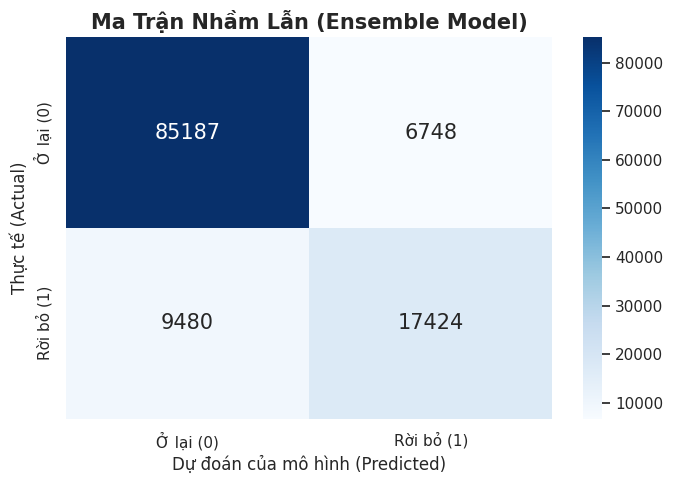

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Đảm bảo y_val (thực tế) là dạng số 0 và 1
le = LabelEncoder()
y_val_numeric = le.fit_transform(y_val)

# 2. Lấy xác suất dự đoán từ mô hình Ensemble
val_preds_proba = ensemble_model.predict_proba(X_val)[:, 1]

# 3. ÉP KIỂU (KHẮC PHỤC LỖI Ở ĐÂY)
# Biến các xác suất thập phân thành nhãn 0 hoặc 1 dựa trên mốc 0.5 (50%)
val_preds_class = (val_preds_proba > 0.5).astype(int)

# 4. Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(y_val_numeric, val_preds_class)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 15})
plt.title('Ma Trận Nhầm Lẫn (Ensemble Model)', fontsize=15, fontweight='bold')
plt.xlabel('Dự đoán của mô hình (Predicted)', fontsize=12)
plt.ylabel('Thực tế (Actual)', fontsize=12)

# Chỉnh lại nhãn trục cho dễ đọc
plt.xticks([0.5, 1.5], ['Ở lại (0)', 'Rời bỏ (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Ở lại (0)', 'Rời bỏ (1)'], fontsize=11, va='center')

plt.tight_layout()
plt.show()